# 🖼️ Contrastive Language-Image Pretraining (CLIP) and Zero-Shot Classification

In traditional computer vision, classifiers are trained to predict a fixed set of predefined classes (e.g., the 1,000 ImageNet categories). If you want your model to recognize a new class (like "electric scooter"), you have to gather new labeled training images and retrain or fine-tune the model's final classification layer.

In 2021, OpenAI introduced **CLIP (Contrastive Language-Image Pretraining)** in a paper titled **"Learning Transferable Visual Models From Natural Language Supervision"**. CLIP represents a massive paradigm shift: it trains a joint text-image embedding space using hundreds of millions of internet images and their captions. This allows it to perform **open-vocabulary, zero-shot image classification** out of the box without any task-specific training data.

### Key Learning Objectives
In this notebook, we will explore:
1. **The Core Architecture:** How the Image Encoder and Text Encoder map multi-modal inputs into a shared vector space.
2. **Contrastive Learning:** The math behind matching positive pairs and pushing apart negative pairs.
3. **Manual Verification:** Extracting features using Hugging Face's pre-trained CLIP and calculating similarity manually to understand the math.
4. **Zero-Shot Classification:** Creating open-vocabulary classifiers and visualizing the output.
5. **Image Retrieval:** Building a simple text-to-image search engine using CLIP embeddings.

## 1. Setup: Libraries

We will install the Hugging Face `transformers` library, which contains the pre-trained CLIP model, and helper libraries like `pillow` for image loading and `ftfy` / `regex` for text preprocessing.

In [1]:
# Install required libraries
!pip install -q transformers ftfy regex tqdm matplotlib pillow requests

import torch
import torch.nn.functional as F
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np
from transformers import CLIPProcessor, CLIPModel

# Check for GPU (Google Colab T4 GPU is perfect here)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
Using device: cuda


## 2. The Core Architecture & Contrastive Learning

CLIP's key innovation is that it does not use a standard classification loss (like Cross-Entropy over a closed vocabulary). Instead, it uses **Contrastive Representation Learning** across two modalities: vision and text.

### 2.1. The Components
1. **Image Encoder ($E_I$):** A neural network that maps raw images into a dense vector embedding $v_i \in \mathbb{R}^D$. This is typically a Vision Transformer (ViT) or a ResNet.
2. **Text Encoder ($E_T$):** A standard text transformer that maps text sentences or words into a dense vector embedding $t_j \in \mathbb{R}^D$.
3. **Projection Layers:** Because the image encoder and text encoder might naturally output vectors of different dimensions, linear projection matrices ($W_I$ and $W_T$) map both output representations into a shared, joint embedding space of the same dimension $D$ (usually 512 or 768).

### 2.2. The Contrastive Objective
Given a batch of $N$ (image, text) pairs, CLIP's goal is to:
* **Maximize** the cosine similarity between the true pairings: $(v_i, t_i)$.
* **Minimize** the cosine similarity between incorrect pairings: $(v_i, t_j)$ where $i \neq j$.

Mathematically, similarity is computed as the dot product of the L2-normalized embeddings:
$$\text{similarity}(v_i, t_j) = \frac{v_i \cdot t_j}{\|v_i\| \|t_j\|}$$

During training, a scaling factor (temperature $\tau$) is applied, and the model is trained end-to-end to maximize the symmetric cross-entropy loss over a similarity matrix of size $N \times N$.

## 3. Loading Model and Sample Images

We will load the pre-trained `openai/clip-vit-base-patch32` model. This model utilizes a ViT-B/32 backbone for images and a text transformer. Both modalities are projected to a shared 512-dimensional embedding space.

Let's download four sample images to test the model: a cat, a dog, a laptop, and a sunset.

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

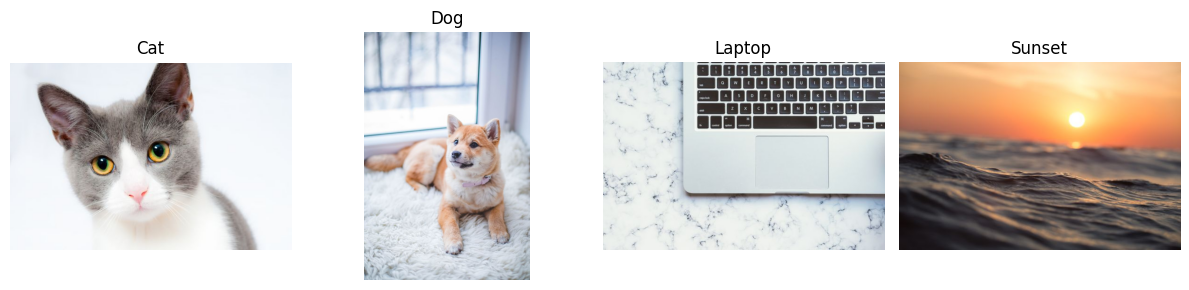

In [13]:
# 1. Load pre-trained CLIP model and processor from Hugging Face
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# 2. Define URLs for our sample images from Pexels (stable open-source image hosting)
image_urls = {
    "cat": "https://images.pexels.com/photos/104827/cat-pet-animal-domestic-104827.jpeg?auto=compress&cs=tinysrgb&w=600",
    "dog": "https://images.pexels.com/photos/1805164/pexels-photo-1805164.jpeg?auto=compress&cs=tinysrgb&w=600",
    "laptop": "https://images.pexels.com/photos/305829/pexels-photo-305829.jpeg?auto=compress&cs=tinysrgb&w=600",
    "sunset": "https://images.pexels.com/photos/189349/pexels-photo-189349.jpeg?auto=compress&cs=tinysrgb&w=600"
}

# 3. Load and display images
images = {}
plt.figure(figsize=(12, 3))
for i, (name, url) in enumerate(image_urls.items()):
    try:
        img = Image.open(requests.get(url, stream=True).raw).convert("RGB")
        images[name] = img
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.title(name.capitalize())
        plt.axis("off")
    except Exception as e:
        print(f"Error loading {name}: {e}")
plt.tight_layout()
plt.show()

## 4. Extracting Embeddings

First, let's look at the shape of the raw text and image embeddings. This shows how CLIP maps different inputs (both pictures and strings) to vectors of identical dimensional size.

In [22]:
# Prepare a single image and multiple text prompts
single_image = images["cat"]
text_prompts = ["a photo of a cat", "a photo of a dog", "a laptop keyboard"]

# Process inputs (resizing, tokenization, and normalization)
inputs = processor(
    text=text_prompts,
    images=single_image,
    return_tensors="pt",
    padding=True
).to(device)

print("Input Keys:", list(inputs.keys()))
print("Pixel values tensor shape:", inputs["pixel_values"].shape)
print("Input IDs tensor shape:", inputs["input_ids"].shape)

# Extract raw visual and textual embeddings into the shared space
with torch.no_grad():
    image_features = model.get_image_features(pixel_values=inputs["pixel_values"])
    text_features = model.get_text_features(input_ids=inputs["input_ids"])

# Standardize output to ensure we are working with tensors
image_features = image_features.pooler_output if hasattr(image_features, "pooler_output") else image_features
text_features = text_features.pooler_output if hasattr(text_features, "pooler_output") else text_features

# Inspect the embedding shapes
print("\nImage Embeddings Shape:", image_features.shape)
print("Text Embeddings Shape:", text_features.shape)

Input Keys: ['input_ids', 'attention_mask', 'pixel_values']
Pixel values tensor shape: torch.Size([1, 3, 224, 224])
Input IDs tensor shape: torch.Size([3, 7])

Image Embeddings Shape: torch.Size([1, 512])
Text Embeddings Shape: torch.Size([3, 512])


## 5. Math Under the Hood: Manual Similarity Calculation

Now we'll replicate the core calculation CLIP performs. To find similarities, we:
1. Normalize the text and image embeddings to unit vectors (magnitude = 1).
2. Perform a matrix multiplication (dot product) between them.
3. Show how the resulting scores map directly to classification probabilities using `softmax`.

> [!NOTE]
> CLIP uses a learned `logit_scale` parameter to scale similarity scores before applying Softmax. This improves classification confidence and models predictive output correctly.

In [18]:
# Normalize the embedding vectors to have an L2 norm of 1
image_features_normalized = image_features / image_features.norm(dim=-1, keepdim=True)
text_features_normalized = text_features / text_features.norm(dim=-1, keepdim=True)

# Calculate cosine similarity using dot product
# [1, 512] x [512, 3] -> [1, 3]
similarity_scores = torch.matmul(image_features_normalized, text_features_normalized.T)

print("Manual Cosine Similarities:")
for prompt, score in zip(text_prompts, similarity_scores[0]):
    print(f" - Similarity with '{prompt}': {score.item():.4f}")

# Compare with the model's forward pass outputs (which scales the similarities before softmax)
with torch.no_grad():
    outputs = model(**inputs)

logits_per_image = outputs.logits_per_image # Raw logits scaled under the hood
probs = logits_per_image.softmax(dim=-1)    # Softmax over text prompts

print("\nModel Softmax Probabilities:")
for prompt, prob in zip(text_prompts, probs[0]):
    print(f" - Probability for '{prompt}': {prob.item() * 100:.2f}%")

Manual Cosine Similarities:
 - Similarity with 'a photo of a cat': 0.2885
 - Similarity with 'a photo of a dog': 0.2347
 - Similarity with 'a laptop keyboard': 0.1851

Model Softmax Probabilities:
 - Probability for 'a photo of a cat': 99.54%
 - Probability for 'a photo of a dog': 0.46%
 - Probability for 'a laptop keyboard': 0.00%


## 6. Open-Vocabulary Zero-Shot Classification

Because CLIP works directly on raw text representations, we can define arbitrary lists of candidate labels. Let's write a utility function to classify any image and visualize it using a horizontal bar plot.

Classifying the dog image:


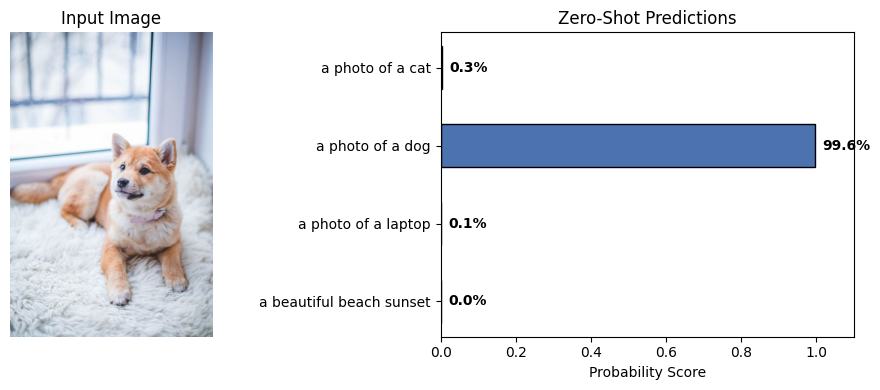


Classifying the sunset image:


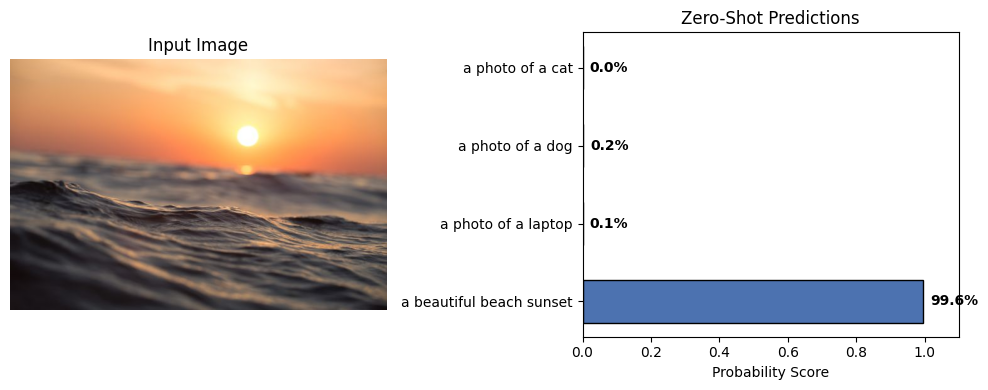

In [19]:
def classify_image(image, candidate_labels):
    # Process inputs
    inputs = processor(
        text=candidate_labels,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    # Run inference
    with torch.no_grad():
        outputs = model(**inputs)
        logits_per_image = outputs.logits_per_image
        probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

    # Visualize the results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Plot input image
    ax1.imshow(image)
    ax1.axis("off")
    ax1.set_title("Input Image")

    # Plot probability horizontal bars
    y_pos = np.arange(len(candidate_labels))
    bars = ax2.barh(y_pos, probs, color="#4C72B0", edgecolor="black", height=0.55)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(candidate_labels, fontsize=10)
    ax2.invert_yaxis()  # Put top prediction at the top
    ax2.set_xlabel("Probability Score")
    ax2.set_xlim(0, 1.1)  # Extra room for label percentages
    ax2.set_title("Zero-Shot Predictions")

    # Add values next to bars
    for bar in bars:
        width = bar.get_width()
        ax2.text(width + 0.02, bar.get_y() + bar.get_height()/2, f"{width * 100:.1f}%",
va="center", ha="left", fontweight="bold")

    plt.tight_layout()
    plt.show()

# Define candidate labels
candidate_classes = [
    "a photo of a cat",
    "a photo of a dog",
    "a photo of a laptop",
    "a beautiful beach sunset"
]

print("Classifying the dog image:")
classify_image(images["dog"], candidate_classes)

print("\nClassifying the sunset image:")
classify_image(images["sunset"], candidate_classes)

## 7. Multi-Modal Retrieval: Text-to-Image Search

Another powerful application of CLIP is image retrieval. Since images and text share a vector space, we can map a text search query to a vector, compute similarities with a database of image embeddings, and return the closest visual match.

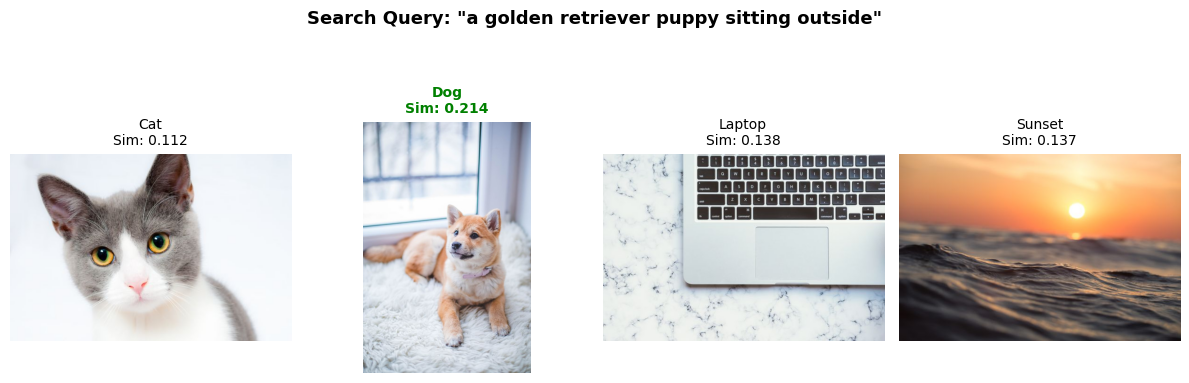

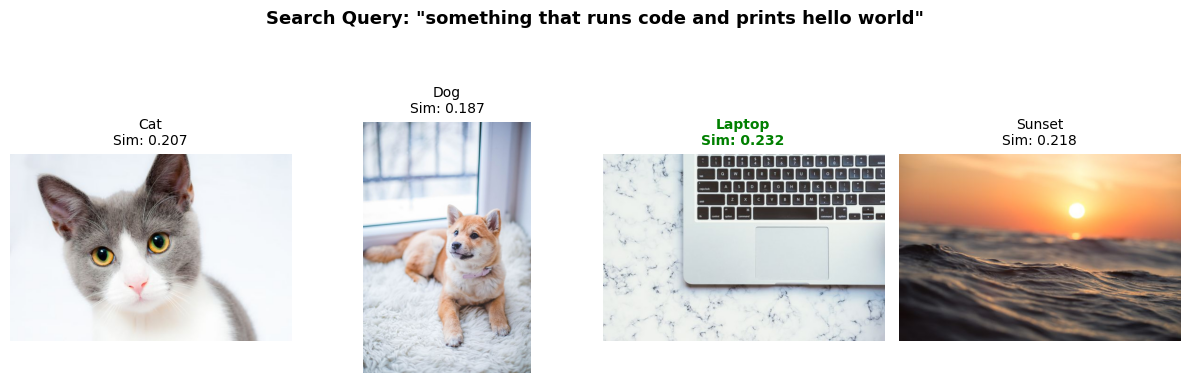

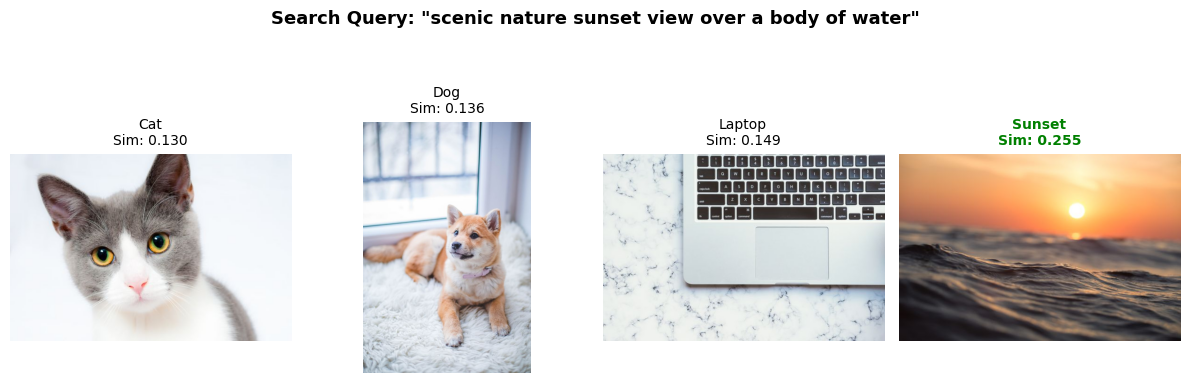

In [23]:
# 1. Create a database of precomputed image features
image_keys = list(images.keys())
image_list = [images[k] for k in image_keys]
inputs_images = processor(images=image_list, return_tensors="pt").to(device)

with torch.no_grad():
    db_image_features = model.get_image_features(**inputs_images)

    # Ensure output is a tensor and normalize
    db_image_features = db_image_features.pooler_output if hasattr(db_image_features, "pooler_output") else db_image_features
    db_image_features /= db_image_features.norm(dim=-1, keepdim=True)

# 2. Image retrieval search query function
def find_best_image(query_text):
    inputs_text = processor(text=[query_text], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        # Extract and normalize query embedding
        query_feature = model.get_text_features(**inputs_text)
        query_feature = query_feature.pooler_output if hasattr(query_feature, "pooler_output") else query_feature
        query_feature /= query_feature.norm(dim=-1, keepdim=True)

        # Compute similarity matrix [1, 512] x [512, 4] -> [1, 4]
        similarities = torch.matmul(query_feature, db_image_features.T).cpu().numpy()[0]

    best_match_idx = np.argmax(similarities)
    best_match_key = image_keys[best_match_idx]

    # Plot database and similarity matches
    fig, axes = plt.subplots(1, len(images), figsize=(12, 3.5))
    fig.suptitle(f"Search Query: \"{query_text}\"", fontsize=13, y=1.08, fontweight="bold")

    for i, key in enumerate(image_keys):
        axes[i].imshow(images[key])
        is_match = (i == best_match_idx)
        title_color = "green" if is_match else "black"
        axes[i].set_title(f"{key.capitalize()}\nSim: {similarities[i]:.3f}", color=title_color, fontsize=10, fontweight="bold" if is_match else "normal")
        axes[i].axis("off")

        if is_match:
            axes[i].patch.set_edgecolor('green')
            axes[i].patch.set_linewidth(4)

    plt.tight_layout()
    plt.show()

# Run retrieval queries
find_best_image("a golden retriever puppy sitting outside")
find_best_image("something that runs code and prints hello world")
find_best_image("scenic nature sunset view over a body of water")

## 8. Summary & Discussion

By bridging Vision and Language, CLIP unlocks incredible flexibility. Let's compare CLIP with traditional CNNs and ViTs:

| Feature | Traditional CNNs/ViTs (ImageNet-1k) | Contrastive Vision-Language Models (CLIP) |
| :--- | :--- | :--- |
| **Classification Classes** | Closed Vocabulary (Predefined $K$ classes) | Open Vocabulary (User-defined prompts at inference) |
| **Downstream Training** | Requires fine-tuning classifier head on target label set | Zero-Shot; requires zero target training samples |
| **Embedding Alignment** | Only models visual similarities | Mathematically aligns visual embeddings with text embeddings |
| **Downstream Tasks** | Limited to specific visual feature classification | Supports Zero-shot classification, Image Retrieval, Multi-modal mapping |

### 💡 Practical Tips for Prompt Engineering in CLIP
* **Prompt Templates:** Instead of search query tokens like `"cat"`, using a template like `"a photo of a cat"` or `"a type of animal, a cat"` yields significantly higher cosine alignment because the pre-training captions were written in natural language.
* **Domain Adaptation:** For specialized domains, customizing prompt prefixes can improve accuracy (e.g. `"a satellite image showing [class]"` or `"a microscopic scan of [class]"`).